In [8]:
import pandas as pd
import numpy as np

# Load the datasets
movies = pd.read_csv('/content/movies.csv')
ratings = pd.read_csv('/content/ratings.csv')

# Display the first few rows to confirm loading
print("Movies Dataset:")
display(movies.head())
print("\nRatings Dataset:")
display(ratings.head())

Movies Dataset:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



Ratings Dataset:


,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [9]:
# Check for missing values
print("Missing values in Movies:\n", movies.isnull().sum())
print("\nMissing values in Ratings:\n", ratings.isnull().sum())

# Remove duplicates
movies.drop_duplicates(inplace=True)
ratings.drop_duplicates(inplace=True)

# Merge datasets so we have titles and ratings in one place
movie_data = pd.merge(ratings, movies, on='movieId')
print("\nMerged Data Sample:")
display(movie_data.head())

Missing values in Movies:
 movieId    0
title      0
genres     0
dtype: int64

Missing values in Ratings:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Merged Data Sample:


,userId,movieId,rating,timestamp,title,genres
0,1,31,2.5,1260759144,Dangerous Minds (1995),Drama
1,1,1029,3.0,1260759179,Dumbo (1941),Animation|Children|Drama|Musical
2,1,1061,3.0,1260759182,Sleepers (1996),Thriller
3,1,1129,2.0,1260759185,Escape from New York (1981),Action|Adventure|Sci-Fi|Thriller
4,1,1172,4.0,1260759205,Cinema Paradiso (Nuovo cinema Paradiso) (1989),Drama


In [10]:
# Calculate average rating and number of ratings for each movie
movie_stats = movie_data.groupby('title')['rating'].agg(['mean', 'count']).reset_index()
movie_stats.columns = ['title', 'avg_rating', 'num_of_ratings']

# Display movies with the most ratings
print("Most Rated Movies:")
display(movie_stats.sort_values(by='num_of_ratings', ascending=False).head(10))

Most Rated Movies:


,title,avg_rating,num_of_ratings
2933,Forrest Gump (1994),4.054252,341
6391,Pulp Fiction (1994),4.256173,324
7084,"Shawshank Redemption, The (1994)",4.487138,311
7166,"Silence of the Lambs, The (1991)",4.138158,304
7488,Star Wars: Episode IV - A New Hope (1977),4.221649,291
4307,Jurassic Park (1993),3.706204,274
5102,"Matrix, The (1999)",4.183398,259
8248,Toy Story (1995),3.872470,247
6918,Schindler's List (1993),4.303279,244
7856,Terminator 2: Judgment Day (1991),4.006329,237


/tmp/ipykernel_4188/2865868140.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='num_of_ratings', y='title', data=top_10, palette='magma')


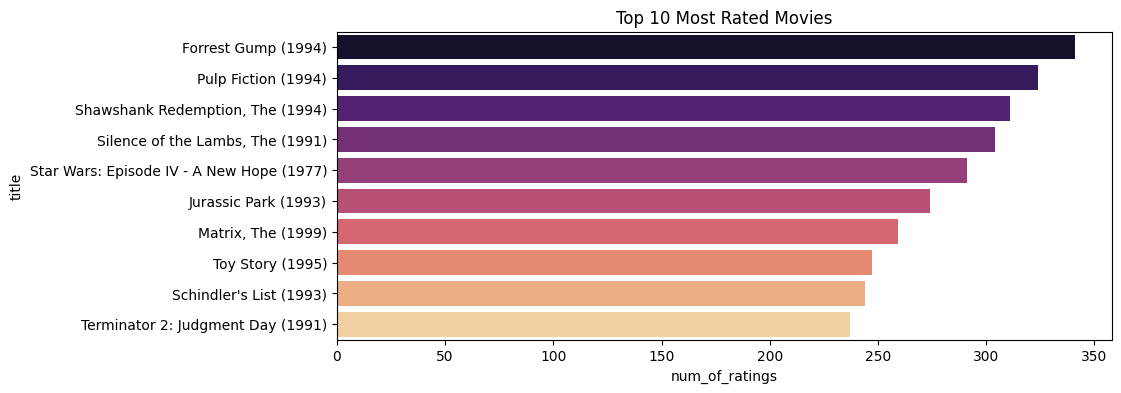

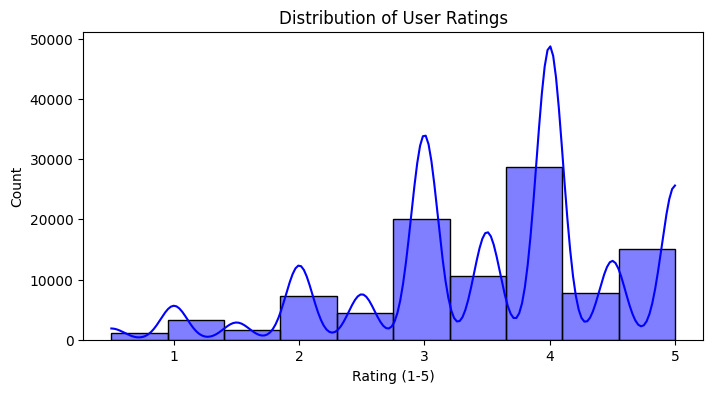

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization 1: Top 10 Popular Movies
plt.figure(figsize=(10,4))
top_10 = movie_stats.sort_values(by='num_of_ratings', ascending=False).head(10)
sns.barplot(x='num_of_ratings', y='title', data=top_10, palette='magma')
plt.title('Top 10 Most Rated Movies')
plt.show()

# Visualization 2: Rating Distribution
plt.figure(figsize=(8,4))
sns.histplot(movie_data['rating'], bins=10, kde=True, color='blue')
plt.title('Distribution of User Ratings')
plt.xlabel('Rating (1-5)')
plt.show()

In [12]:
# Create a matrix where rows are users and columns are movie titles
user_movie_matrix = movie_data.pivot_table(index='userId', columns='title', values='rating')

# Fill NaN (missing) values with 0 so the math works
user_movie_matrix = user_movie_matrix.fillna(0)

display(user_movie_matrix.head())

title,"""Great Performances"" Cats (1998)",$9.99 (2008),'Hellboy': The Seeds of Creation (2004),'Neath the Arizona Skies (1934),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),...,Zulu (1964),Zulu (2013),[REC] (2007),eXistenZ (1999),loudQUIETloud: A Film About the Pixies (2006),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931),İtirazım Var (2014)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
# Select a movie to test (e.g., 'Toy Story (1995)')
test_movie_ratings = user_movie_matrix['Toy Story (1995)']

# Find correlation of 'Toy Story' with all other movies
similar_to_test_movie = user_movie_matrix.corrwith(test_movie_ratings)

# Create a dataframe to show the correlation results
corr_summary = pd.DataFrame(similar_to_test_movie, columns=['Correlation'])
corr_summary.dropna(inplace=True)

# Join with movie_stats to ensure we only suggest movies with enough ratings
corr_summary = corr_summary.join(movie_stats.set_index('title')['num_of_ratings'])

# Filter movies that have more than 50 ratings to ensure quality suggestions
recommendations = corr_summary[corr_summary['num_of_ratings'] > 50].sort_values('Correlation', ascending=False)

print("Movies similar to 'Toy Story (1995)':")
display(recommendations.head(10))

Movies similar to 'Toy Story (1995)':


,Correlation,num_of_ratings
title,,
Toy Story (1995),1.000000,247
Toy Story 2 (1999),0.474141,125
"Bug's Life, A (1998)",0.393799,105
Groundhog Day (1993),0.372371,165
"Monsters, Inc. (2001)",0.366277,130
Independence Day (a.k.a. ID4) (1996),0.356876,218
Finding Nemo (2003),0.348941,122
"Incredibles, The (2004)",0.346066,126
Shrek (2001),0.344068,174
